# Land Type Classification using Sentinel-2 Satellite Images
***

#### Some tests for GPU `tensorflow`

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.python.platform.build_info import build_info

print("CUDA:", build_info["cuda_version"])
print("cuDNN:", build_info["cudnn_version"])

CUDA: 64_112
cuDNN: 64_8


#### Limited VRAM usage as CUDA allocate the whole entirety of VRAM

In [3]:
# from tensorflow.config.experimental import list_physical_devices, VirtualDeviceConfiguration, set_virtual_device_configuration #type:ignore
# vram_GB = 2 
# gpus = list_physical_devices('GPU')
# if gpus:
#     try:
#         set_virtual_device_configuration( gpus[0], [VirtualDeviceConfiguration(memory_limit= vram_GB * 1024)] )
#         print(f"[/] Limited GPU memory to {vram_GB} GB.")
#     except RuntimeError as e:
#         print(e)

### Had to re-define `CategoricalFocalLoss` as it was missing in this old version of tensorflow
 - should have the same functionanlity

In [4]:
import tensorflow as tf
from tensorflow.keras.losses import Loss #type:ignore
from tensorflow.keras import backend as K #type:ignore

class CategoricalFocalLoss(Loss):
    """
    Categorical focal loss for one-hot labels.
    Usage:
        loss = CategoricalFocalLoss(gamma=2.0, alpha=0.25)
        model.compile(..., loss=loss, ...)
    """
    def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="categorical_focal_loss"):
        super().__init__(reduction=reduction, name=name)
        self.gamma = float(gamma)
        self.alpha = float(alpha) if alpha is not None else None
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        """
        y_true: one-hot (batch, classes)
        y_pred: probabilities (softmax) or logits if from_logits=True
        """
        # If logits provided, convert to probabilities
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        # Clip to avoid log(0) and NaNs
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)

        # Compute cross-entropy per class
        cross_entropy = -y_true * K.log(y_pred)  # shape (batch, classes)

        # get p_t: the model probability for the true class per sample (elementwise y_true * y_pred)
        p_t = y_true * y_pred  # (batch, classes)

        # focal weighting: (1 - p_t)^gamma
        focal_factor = K.pow(1.0 - p_t, self.gamma)

        if self.alpha is not None:
            alpha_factor = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
            # For multiclass one-hot alpha factor reduces to alpha for true class; keep simple:
            alpha_factor = y_true * self.alpha  # only apply alpha to true class entries
        else:
            alpha_factor = 1.0

        # elementwise focal loss
        loss = alpha_factor * focal_factor * cross_entropy  # (batch, classes)

        # sum over classes then mean over batch
        loss = K.sum(loss, axis=-1)
        return K.mean(loss)

    def get_config(self):
        return {"gamma": self.gamma, "alpha": self.alpha, "from_logits": self.from_logits}


***
# Normal Code

In [5]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import csv

from tensorflow.keras.regularizers import l2 #type:ignore
from tensorflow.keras.optimizers import Adam, RMSprop, SGD #type:ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.applications import EfficientNetB3 #type:ignore
from sklearn.utils.class_weight import compute_class_weight
#from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout #type:ignore
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D #type:ignore
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [6]:
from pathlib import Path
import os
import shutil
import random

#### Split data into folders

In [7]:
project_root = Path(os.getcwd())

dataset_root = project_root / "Dataset"
original_folder = dataset_root / "EuroSAT_RGB"
base_folder = dataset_root / "EuroSAT_RGB_split"

checkpoints_dir = project_root


print("Project Root:       ",project_root)
print("Dataset Root:       ",dataset_root)
print("Original Root:      ",original_folder)
print("Base Folder:        ",base_folder)
print("Checkpoints Folder: ",checkpoints_dir)

Project Root:        d:\Coding\Jupyter\DEPI\DEPI-Final-Project
Dataset Root:        d:\Coding\Jupyter\DEPI\DEPI-Final-Project\Dataset
Original Root:       d:\Coding\Jupyter\DEPI\DEPI-Final-Project\Dataset\EuroSAT_RGB
Base Folder:         d:\Coding\Jupyter\DEPI\DEPI-Final-Project\Dataset\EuroSAT_RGB_split
Checkpoints Folder:  d:\Coding\Jupyter\DEPI\DEPI-Final-Project


In [8]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [9]:
#split_data()


#### split_data() Output:
 - AnnualCrop: 3000 images split into train/val/test
 - Forest: 3000 images split into train/val/test
 - HerbaceousVegetation: 3000 images split into train/val/test
 - Highway: 2500 images split into train/val/test
 - Industrial: 2500 images split into train/val/test
 - Pasture: 2000 images split into train/val/test
 - PermanentCrop: 2500 images split into train/val/test
 - Residential: 3000 images split into train/val/test 
 - River: 2500 images split into train/val/test 
 - SeaLake: 3000 images split into train/val/test


In [10]:
train_dir = base_folder / "train"
val_dir = base_folder / "validate"
test_dir = base_folder / "test"

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


In [12]:
class_labels = train_generator.classes
class_weight_dict = dict(
    enumerate(
        compute_class_weight('balanced', classes=np.unique(class_labels), y=class_labels)
    )
)
class_weight_dict

{0: 0.9,
 1: 0.9,
 2: 0.9,
 3: 1.08,
 4: 1.08,
 5: 1.35,
 6: 1.08,
 7: 0.9,
 8: 1.08,
 9: 0.9}

***
### **Model (**`CNN`**) Training**

In [13]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

        
callbacks = [
    ModelCheckpoint(str(checkpoints_dir / f'model.h5'), monitor='val_loss', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
]

params = { 
    'filters': 64,
    'conv_layers': 4,
    'dense_units': 256, 
    'dropout': 0.4, 
    'batch_norm': True, 
    'optimizer': "adam", 
    'lr': 1e-4, 
    'flattening_layers': "GAP2D"
}

model = Sequential()
filters = params['filters']
for i in range(params['conv_layers']):
    if i == 0:
        model.add(Conv2D(filters, (3,3), activation='relu',kernel_regularizer=l2(0.001) ,input_shape=(64, 64, 3)))
    else:
        model.add(Conv2D(filters, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))
    if params['batch_norm']:
        model.add(BatchNormalization())
    filters *= 2  # Double filters each block
    
if params["flattening_layers"] == "GAP2D":
    model.add(GlobalAveragePooling2D())
    model.add(Dense(params['dense_units'], activation='relu', kernel_regularizer=l2(0.001)))
else:
    model.add(Flatten())
    model.add(Dense(params['dense_units'], activation='relu'))
    
model.add(Dropout(params['dropout']))
model.add(Dense(train_generator.num_classes, activation='softmax'))

if params['optimizer'] == 'adam':
    opt = Adam(learning_rate=params['lr'])
elif params['optimizer'] == 'rmsprop':
    opt = RMSprop(learning_rate=params['lr'])
else:
    opt = SGD(learning_rate=params['lr'], momentum=0.9)
    

model.compile(
    optimizer=opt, 
    loss=CategoricalFocalLoss(gamma=2.0, alpha=0.25, from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
591/591 [==============================] - 26s 38ms/step - loss: 0.4779 - accuracy: 0.6606 - val_loss: 0.5076 - val_accuracy: 0.5751 - lr: 1.0000e-04
Epoch 2/50
591/591 [==============================] - 25s 41ms/step - loss: 0.3854 - accuracy: 0.7579 - val_loss: 0.3662 - val_accuracy: 0.7640 - lr: 1.0000e-04
Epoch 3/50
591/591 [==============================] - 121s 204ms/step - loss: 0.3303 - accuracy: 0.7980 - val_loss: 0.3005 - val_accuracy: 0.8237 - lr: 1.0000e-04
Epoch 4/50
591/591 [==============================] - 22s 37ms/step - loss: 0.2849 - accuracy: 0.8180 - val_loss: 0.2821 - val_accuracy: 0.7746 - lr: 1.0000e-04
Epoch 5/50
591/591 [==============================] - 22s 37ms/step - loss: 0.2436 - accuracy: 0.8378 - val_loss: 0.2139 - val_accuracy: 0.8723 - lr: 1.0000e-04
Epoch 6/50
591/591 [==============================] - 22s 37ms/step - loss: 0.2079 - accuracy: 0.8567 - val_loss: 0.1976 - val_accuracy: 0.8573 - lr: 1.0000e-04
Epoch 7/50
591/591 [============

***
#### Load Model

In [14]:
#model = tf.keras.models.load_model("model.h5")

#### print used VRAM

In [15]:
gpus = tf.config.list_physical_devices('GPU')
details = tf.config.experimental.get_memory_info(gpus[0].name[17:])
print(f"GPU: {gpus[0].name}")
print(f"  Used VRAM: {details['current'] / 1024**2:.2f} MB")
print(f"  Peak VRAM: {details['peak'] / 1024**2:.2f} MB")

GPU: /physical_device:GPU:0
  Used VRAM: 21.08 MB
  Peak VRAM: 780.31 MB


#### **Model Test**
**Returns:**
 - Test Accuracy
 - Test Loss
 - y Predict

In [16]:
def evaluate_model(model, test_ds, class_names):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Results:\nAccuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    preds = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    if hasattr(test_ds, 'labels'):
        y_true = test_ds.labels
    else:
        y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return test_acc, test_loss, y_pred


Test Results:
Accuracy: 0.9378 | Loss: 0.0361
127/127 [==============================] - 2s 14ms/step


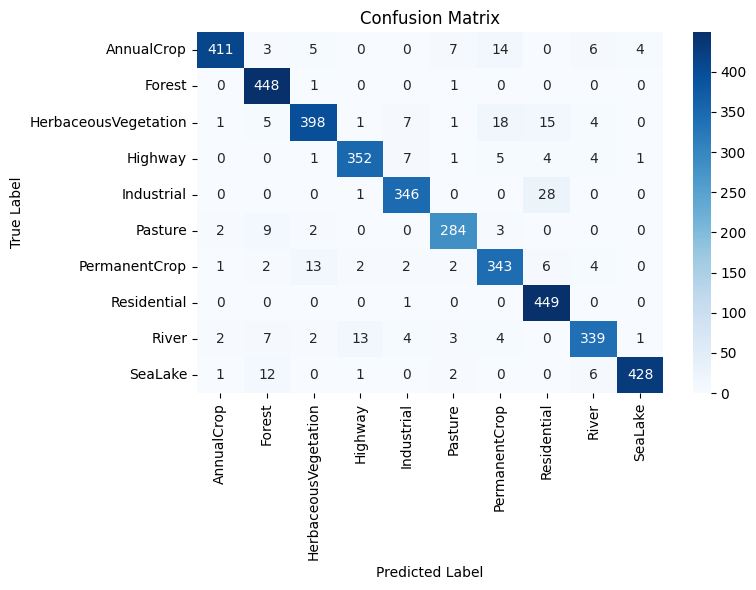


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9833    0.9133    0.9470       450
              Forest     0.9218    0.9956    0.9573       450
HerbaceousVegetation     0.9431    0.8844    0.9128       450
             Highway     0.9514    0.9387    0.9450       375
          Industrial     0.9428    0.9227    0.9326       375
             Pasture     0.9435    0.9467    0.9451       300
       PermanentCrop     0.8863    0.9147    0.9003       375
         Residential     0.8944    0.9978    0.9433       450
               River     0.9339    0.9040    0.9187       375
             SeaLake     0.9862    0.9511    0.9683       450

            accuracy                         0.9378      4050
           macro avg     0.9387    0.9369    0.9370      4050
        weighted avg     0.9392    0.9378    0.9377      4050

Test Accuracy: 0.9378
Test Loss: 0.0361


In [17]:
test_acc, test_loss, y_pred = evaluate_model(model, test_generator, list(test_generator.class_indices.keys()))
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

***
#### **Plot Training Process**

In [18]:
def plot_training_curves(model, test_acc=0):
    acc = model.history['accuracy']
    val_acc = model.history['val_accuracy']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.axhline(y=test_acc, linestyle='--', color='green', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

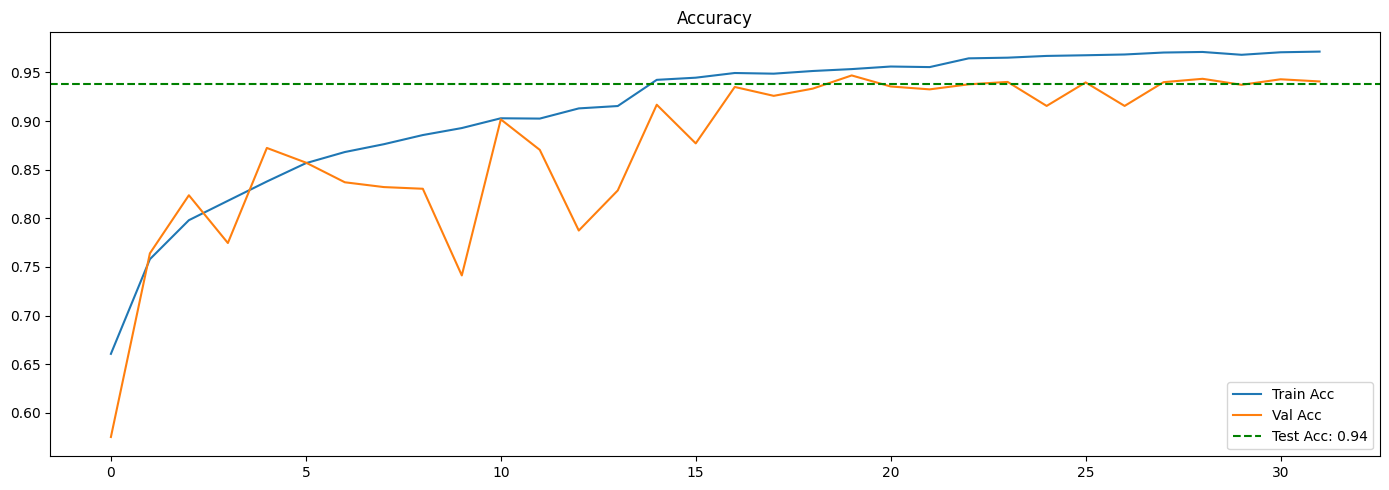

In [19]:
plot_training_curves(history, test_acc=test_acc)

***
#### Pick **Random** Image as test

1/1 [==============================] - 0s 219ms/step


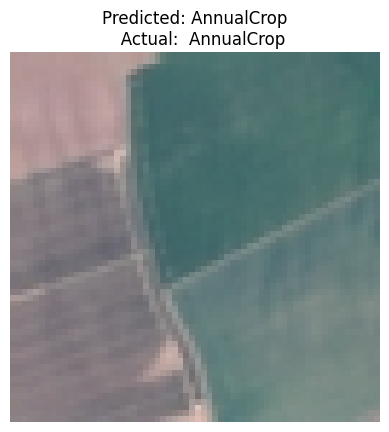

In [20]:
basefolder = dataset_root / "EuroSAT_RGB_split"
img_size = (64, 64)
class_names = list(test_generator.class_indices.keys())

all_image_paths = []

for split_dir in os.listdir(basefolder):
    split_path = os.path.join(basefolder, split_dir)
    if os.path.isdir(split_path):
        for class_dir in os.listdir(split_path):
            class_path = os.path.join(split_path, class_dir)
            if os.path.isdir(class_path):
                for fname in os.listdir(class_path):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        full_path = os.path.join(class_path, fname)
                        all_image_paths.append(full_path)


random_image_path = random.choice(all_image_paths)
image_type = random_image_path.split("\\")[-1].split("_")[0]

img = cv2.imread(random_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #type: ignore
img_resized = cv2.resize(img, img_size)
img_array = np.expand_dims(img_resized, axis=0) / 255.0  # normalize

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_class}\n   Actual:  {image_type}")
plt.axis('off')
plt.show()